In [1]:
from sympy import false
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import pydicom
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, loaders, Beam
from pydose_rt.utils.utils import sample_tensor_nearest
from pydose_rt.physics.fluence.fluence_modeling import compute_profile_ratios, create_radial_correction_map

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype=torch.float32

do_plot = True

measurements = loaders.load_asc_measurements("/home/bolo/Documents/PyDoseRT/test_data/10 MV Photons/TrueBeam X10 Squares OK.asc", coord_map=("X", "Z", "Y"))
field_size = 400

measurements = [measurement for measurement in measurements if measurement["header_dict"]["FSZ"] == [str(field_size), str(field_size)]]
measurements = [measurement for measurement in measurements if measurement["header_dict"]["EDS"][2] == measurement["header_dict"]["STS"][2]]
measurements = [measurement for measurement in measurements if (float(measurement["header_dict"]["STS"][2]) == 100.0) and (float(measurement["header_dict"]["EDS"][2]) == 100.0)]

In [2]:
resolution = (1.0, 1.0, 1.0)
ct_array_shape = (500, 500, 500)
phantom = Phantom.from_uniform_water(shape=ct_array_shape, spacing=resolution).to(device).to(dtype)
number_of_beams=1
starting_angle=0
iso_center=(250.0, 100.0, 250.0)
kernel_size=501
beam = Beam.create(
    gantry_angle_deg=0.0, 
    number_of_leaf_pairs=60, 
    collimator_angle_deg=0.0, 
    field_size_mm=(field_size, field_size),
    iso_center=iso_center, 
    device=device, 
    dtype=dtype)

In [3]:

machine_config = MachineConfig(
    preset="../../src/pydose_rt/data/machine_presets/umea_10MV.json",
    profile_corrections=None,
    output_factors=None
    )
dose_engine = DoseEngine(
    machine_config, 
    kernel_size,
    phantom._resolution,
    image_template=phantom.density_image,
    beam_template=beam,
    device=device,
    dtype=dtype,
    adjust_values=False
)
dose_engine.calibrate(110)

dose = dose_engine.compute_dose(
    beam,
    ct_image=phantom.density_image).detach()


Calibration failed. Adjusting calibration factor to: 0.0012620772491840943


In [4]:
data = []

for i, measurement in enumerate(measurements):
    samples = sample_tensor_nearest(dose[0, ...], resolution, np.subtract(iso_center, (0.5, 100.5, 0.5)), measurement["coords_engine"])
    samples = samples * measurement["dose"].max() / samples.max()
    mape = np.mean(np.abs(samples - measurement["dose"])[measurement["dose"] > 0] /  measurement["dose"][measurement["dose"] > 0])
    thr_20 = 0.2 * measurement["dose"].max()
    thr_80 = 0.8 * measurement["dose"].max()
    penumbra_pred = sum((samples > thr_20) * (samples < thr_80))
    penumbra_measurement = sum((measurement["dose"] > thr_20) * (measurement["dose"] < thr_80))

    coords = measurement["coords_engine"]  # shape (N, 3) presumably

    # Indices of coordinates that actually change
    var_mask = np.var(coords, axis=0) != 0
    changing_idx = np.where(var_mask)[0]

    if changing_idx.size == 0:
        raise ValueError("No changing coordinates found in coords_engine.")

    # Compute physical distance along the line (only over changing components)
    # This works for 1D, 2D (diagonal), or 3D profiles
    diffs = np.diff(coords[:, changing_idx], axis=0)              # (N-1, k)
    seg_len = np.linalg.norm(diffs, axis=1)                       # (N-1,)
    dist = np.concatenate(([0.0], np.cumsum(seg_len)))            # (N,)
    ticks = dist - np.mean(dist)                                  # center at 0
    num_points = len(ticks)//2
    data.append((ticks[num_points::2], samples[num_points::2], measurement["dose"][num_points::2]))



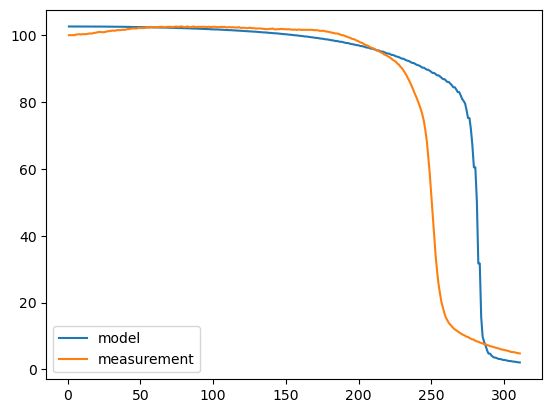

In [5]:
plt.plot(data[0][0], data[0][1], label="model")
plt.plot(data[0][0], data[0][2], label="measurement")
plt.legend()

In [6]:

# Stage 1: Compute sampled ratios
num_sampling_points = data[0][0].shape[0]
sample_points = np.linspace(0, 310, 311, endpoint=True)  # [0, 10, 20, ..., 500]
distances, ratios = compute_profile_ratios(
    data[0][2], data[0][1], data[0][0], sample_points
)

print(f"Sampled {len(ratios)} points")
print(f"Sample distances: {distances[:5]}... {distances[-5:]}")
print(f"Sample ratios: {ratios[:5]}... {ratios[-5:]}")


Sampled 311 points
Sample distances: [0. 1. 2. 3. 4.]... [306. 307. 308. 309. 310.]
Sample ratios: [0.97442774 0.97467116 0.9746518  0.97468052 0.97458506]... [2.18668392 2.20948061 2.19722727 2.24801604 2.26565698]


In [7]:
# Stage 2: Create correction map
image_shape = (num_sampling_points*2, num_sampling_points*2)  # height, width
pixel_size = 1.0  # 1 mm per pixel
    
correction_map = create_radial_correction_map(
    distances,
    ratios,
    image_shape,
    pixel_size,
).cpu().detach().numpy()

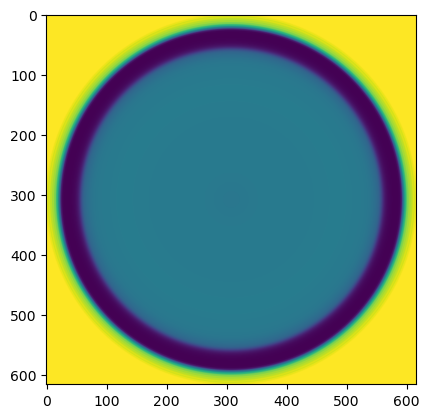

In [8]:
plt.imshow(correction_map)

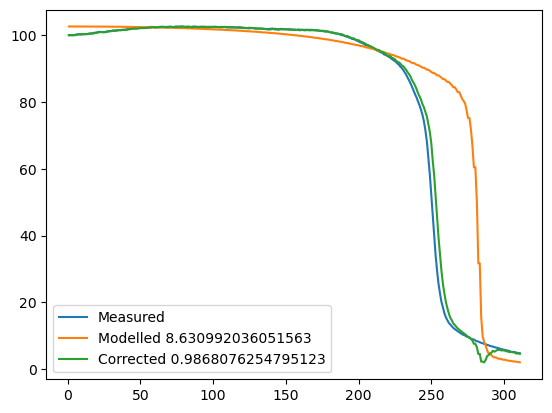

In [9]:
plt.plot(data[0][0], data[0][2], label="Measured")
plt.plot(data[0][0], data[0][1], label=f"Modelled {np.mean(np.abs(data[0][2] - data[0][1]))}")
plt.plot(data[0][0], correction_map[num_sampling_points:, num_sampling_points] * data[0][1], label=f"Corrected {np.mean(np.abs(data[0][2] - correction_map[num_sampling_points:, num_sampling_points] * data[0][1]))}")
plt.legend(loc="lower left")

In [10]:

profiles = np.round(np.stack([distances, ratios], 0), 4)

def fmt(x):
    s = np.format_float_positional(x, trim='-')
    return s if '.' in s else s + '.0'

formatted = np.array2string(
    profiles,
    formatter={'float_kind': fmt},
    separator=', '       # ← comma between values
)

print(formatted)

[[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0,
  13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0,
  25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0,
  37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0,
  49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0,
  61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0,
  73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0,
  85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0,
  97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0,
  107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0,
  117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0,
  127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0,
  137.0, 138.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0, 146.0,
  147.0, 148.0, 149.0, 150.0, 151.0, 152.0, 153.0, 154.